In [11]:
import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.nn import GCNConv
from torch_geometric.utils import from_networkx, negative_sampling
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pd

In [12]:
def build_graph():
    G = nx.Graph()

    # Define automorphic structure: 4-node cycle
    auto_edges = [(0,1), (1,2), (2,3), (3,0)]
    G.add_edges_from(auto_edges)

    # Add some unique connections
    non_auto_edges = [(4,0), (5,2)]
    G.add_edges_from(non_auto_edges)

    # Constant node features
    for n in G.nodes():
        G.nodes[n]['x'] = [1.0]

    # Draw the graph with automorphic vs. non-automorphic edge colors
    pos = nx.spring_layout(G, seed=42)
    edge_colors = ['red' if e in auto_edges or (e[1], e[0]) in auto_edges else 'gray' for e in G.edges()]
    node_colors = ['lightcoral' if n in [0,1,2,3] else 'skyblue' for n in G.nodes()]

    plt.figure(figsize=(6, 5))
    nx.draw(G, pos, with_labels=True, edge_color=edge_colors, node_color=node_colors, width=2.0, node_size=600)
    plt.title("Graph with Automorphic (Red) and Non-Automorphic (Gray) Edges")
    plt.show()

    return from_networkx(G), auto_edges, G


In [13]:
class GCN(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

class LinkPredictor(torch.nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.lin = Linear(2 * dim, 1)

    def forward(self, x_i, x_j):
        return torch.sigmoid(self.lin(torch.cat([x_i, x_j], dim=-1))).squeeze(-1)

In [14]:
def run():
    data, auto_edges, G_nx = build_graph()
    edge_index = data.edge_index
    data.x = torch.tensor([d['x'] for _, d in G_nx.nodes(data=True)], dtype=torch.float)

    model = GCN(1, 16)
    predictor = LinkPredictor(16)
    optimizer = torch.optim.Adam(list(model.parameters()) + list(predictor.parameters()), lr=0.01)

    neg_edge_index = negative_sampling(edge_index, data.num_nodes, edge_index.size(1))
    all_edge_index = torch.cat([edge_index, neg_edge_index], dim=1)
    labels = torch.cat([torch.ones(edge_index.size(1)), torch.zeros(neg_edge_index.size(1))])

    for _ in range(100):
        model.train()
        x = model(data.x, edge_index)
        src, dst = all_edge_index
        pred = predictor(x[src], x[dst])
        loss = F.binary_cross_entropy(pred, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    x = model(data.x, edge_index).detach()

    tsne = TSNE(n_components=2, perplexity=2,random_state=0)
    x_2d = tsne.fit_transform(x.numpy())

    # Plot node embeddings
    plt.figure(figsize=(8,6))
    for i, (x_, y_) in enumerate(x_2d):
        color = 'red' if i in [0,1,2,3] else 'blue'
        plt.scatter(x_, y_, c=color)
        plt.text(x_ + 0.02, y_ + 0.02, str(i), fontsize=9)
    plt.title("2D Visualization of Node Embeddings")
    plt.show()
    
    
    pos = nx.spring_layout(G_nx, seed=42)
    node_colors = ['red' if n in [0,1,2,3] else 'skyblue' for n in G_nx.nodes()]
    plt.figure(figsize=(6,6))
    nx.draw(G_nx, pos, with_labels=True, node_color=node_colors, node_size=600)
    plt.title("Original Graph (Red = Automorphic Nodes)")
    plt.show()
    
    preds, types = [], []
    for i in range(all_edge_index.shape[1]):
        s, d = int(all_edge_index[0, i]), int(all_edge_index[1, i])
        pred = predictor(x[s].unsqueeze(0), x[d].unsqueeze(0)).item()
        t = 'A' if (s,d) in auto_edges or (d,s) in auto_edges else 'NA'
        preds.append(pred)
        types.append(t)

    df = pd.DataFrame({"Prediction": preds, "EdgeType": types})
    df.boxplot(column="Prediction", by="EdgeType")
    plt.title("Link Prediction Score by Edge Type")
    plt.suptitle("")
    plt.ylabel("Score")
    plt.show()

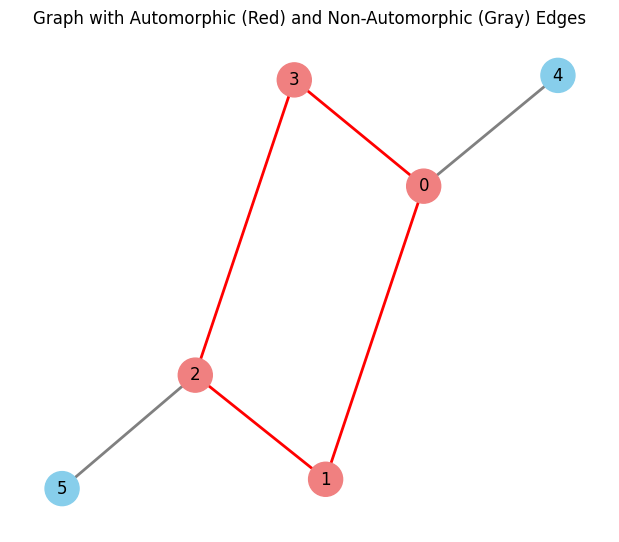

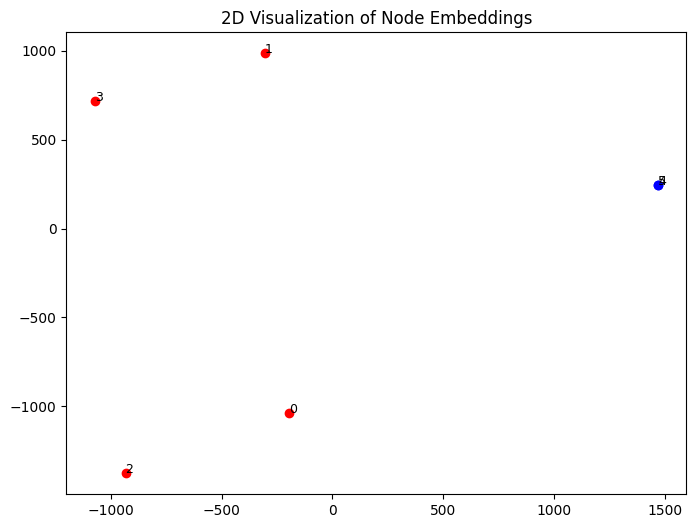

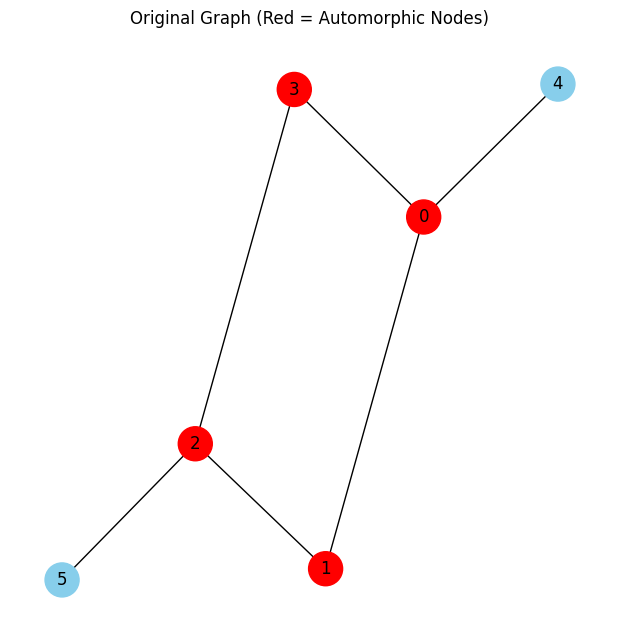

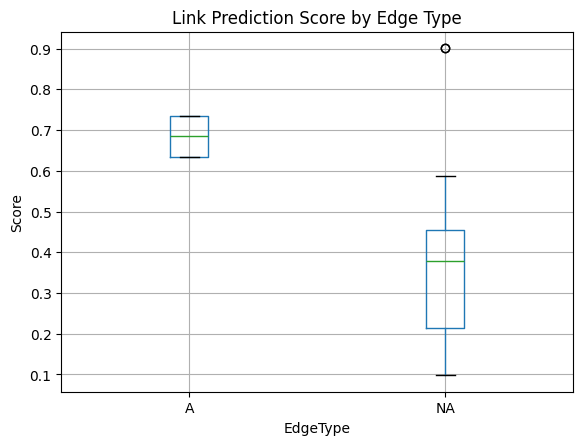

In [15]:
run()